# 1. Half reactions, balancing, and oxidation states

This notebook covers the basics: naming a redox couple, seeing it balanced,
reading off the potentials, and producing the stacked half-reaction figure.

Every number here is computed from pyGCC at the stated conditions. Nothing is
read from a stored table.

In [1]:
import warnings

import matplotlib.pyplot as plt

import microbial_thermo as mt

warnings.filterwarnings("ignore", category=UserWarning)
mt.versions()

{'microbial_thermo': '0.1.0',
 'pygcc': '1.5.3',
 'numpy': '2.4.6',
 'pandas': '2.3.3',
 'scipy': '1.17.1',
 'chempy': '0.10.1',
 'sympy': '1.14.0',
 'pint': '0.25.3',
 'matplotlib': '3.11.1',
 'plotly': '7.0.0'}

## A single couple

Couples are always written `(reduced, oxidized)`. The library works out which
element changes oxidation state and balances the half reaction: the redox
element first, then oxygen with water, hydrogen with protons, and charge with
electrons.

In [2]:
from microbial_thermo.reaction import Couple, HalfReactionResult

conditions = mt.Conditions(temperature_c=25.0, pH=7.0)

couple = Couple.make("HS-", "SO4-2")
half = HalfReactionResult(
    couple=couple,
    half=couple.half_reaction(),
    conditions=conditions,
    backend=mt.get_backend(),
)

print("as a reduction:", half.half.format("reduction"))
print("as an oxidation:", half.half.format("oxidation"))
print("electrons transferred:", half.n_electrons)
print(f"E0  = {half.E_standard.to('V').magnitude:+.3f} V")
print(f"E0' = {half.E_standard_prime.to('V').magnitude:+.3f} V")

as a reduction: SO4-- + 9 H+ + 8 e- -> HS- + 4 H2O
as an oxidation: HS- + 4 H2O -> SO4-- + 9 H+ + 8 e-
electrons transferred: 8


E0  = +0.249 V
E0' = -0.217 V


`E0` is at unit activity of everything, including $[\mathrm{H^+}] = 1$ M.
`E0'` holds everything at unit activity but puts protons at the pH given in
the conditions. The gap between them is the proton stoichiometry at work.

A couple with no protons in it shows no gap at all:

In [3]:
for reduced, oxidized in [("HS-", "SO4-2"), ("Fe+2", "Fe+3"), ("H2(g)", "H+")]:
    pair = Couple.make(reduced, oxidized)
    result = HalfReactionResult(
        couple=pair, half=pair.half_reaction(),
        conditions=conditions, backend=mt.get_backend(),
    )
    print(
        f"{str(pair):22s} E0 = {result.E_standard.to('V').magnitude:+.3f} V   "
        f"E0' = {result.E_standard_prime.to('V').magnitude:+.3f} V"
    )

SO4--/HS-              E0 = +0.249 V   E0' = -0.217 V
Fe+++/Fe++             E0 = +0.770 V   E0' = +0.770 V
H+/H2(g)               E0 = -0.000 V   E0' = -0.414 V


## Oxidation states

The figures report the *mean* oxidation state of the redox-active element,
as exact fractions rather than rounded decimals.

In [4]:
from microbial_thermo.oxidation import format_oxidation_state

for element, formula in [
    ("S", "SO4-2"), ("S", "HS-"), ("N", "NO3-"), ("C", "CH4"),
    ("C", "C2H3O2-"), ("Fe", "Fe3O4"), ("Mn", "MnO2"),
]:
    state = mt.mean_oxidation_state(element, formula)
    print(f"{element} in {formula:10s} {format_oxidation_state(state):>6s}")

S in SO4-2          +6
S in HS-            -2
N in NO3-           +5
C in CH4            -4
C in C2H3O2-         0
Fe in Fe3O4        +8/3
Mn in MnO2           +4


For organic molecules the per-atom states are available too, from the bond
graph. Acetate's two carbons are chemically distinct — the methyl carbon is
at −3 and the carboxyl at +3 — even though their mean is 0.

In [5]:
print("acetate per-atom:", mt.atom_oxidation_states("CC(=O)[O-]"))
print("acetate NOSC (the mean):", mt.nosc("C2H3O2-"))

acetate per-atom: [('C', -3), ('C', 3), ('O', -2), ('O', -2), ('H', 1), ('H', 1), ('H', 1)]
acetate NOSC (the mean): 0


## A whole reaction

Pair a donor with an acceptor. The donor runs in the oxidative direction, the
acceptor in the reductive one, and both are scaled so the electrons cancel.

In [6]:
reaction = mt.Reaction.from_couples(
    donor=("H2(g)", "H+"),
    acceptor=("HS-", "SO4-2"),
    conditions=conditions,
    normalize_to="integer",
)
print(reaction.summary())

Reaction:  H+ + 4 H2(g) + SO4-- -> HS- + 4 H2O
  donor     H+/H2(g)  (oxidative)  E0' = -0.414 V
  acceptor  SO4--/HS-  (reductive)  E0' = -0.217 V
  n electrons        8
  dE0'               +0.197 V
  dG0'               -152.3 kJ/mol
  dG (conditions)    -152.3 kJ/mol
  dG per electron    -19.0 kJ/mol e-


## Show your work

Every number can be traced back to its origin: which species contributed
which formation energy, how each term of the reaction quotient was formed,
and where the Nernst factor came from.

In [7]:
reaction.show_work()

## Derivation: H+ + 4 H2(g) + SO4-- -> HS- + 4 H2O

**Step 1. Identify the redox couples**

- Electron donor: H+/H2(g) — H goes from +1 on the oxidized side to 0 on the reduced side
- Electron acceptor: SO4--/HS- — S goes from +6 on the oxidized side to -2 on the reduced side
- The donor is written in the oxidative direction and the acceptor in the reductive direction, normalised to 8 electrons.

**Step 2. Balance each half reaction**

Balance the redox-active element first, then oxygen with $\mathrm{H_2O}$, hydrogen with $\mathrm{H^+}$, and finally charge with electrons.

Oxidation (electron donor):
$$ 4\,\mathrm{H_2(g)} \longrightarrow 8\,\mathrm{H^+} + 8\,\mathrm{e^-} $$
Reduction (electron acceptor):
$$ \mathrm{SO_4^{2-}} + 9\,\mathrm{H^+} + 8\,\mathrm{e^-} \longrightarrow \mathrm{HS^-} + 4\,\mathrm{H_2O} $$

**Step 3. Add the half reactions so the electrons cancel**

$$ \mathrm{H^+} + 4\,\mathrm{H_2(g)} + \mathrm{SO_4^{2-}} \longrightarrow \mathrm{HS^-} + 4\,\mathrm{H_2O} $$
Both halves are scaled to 8 electrons, so the electrons cancel exactly and the sum conserves atoms and charge.

**Step 4. Look up standard formation energies**

At 25 °C from pygcc 1.5.3 (speq21.dat (pyGCC default)):

| species | ν | ΔG°f (kJ/mol) | ν·ΔG°f |
|---|---:|---:|---:|
| H+ | -1 | 0.00 | -0.00 |
| H2(g) | -4 | 0.00 | -0.00 |
| H2O | +4 | -237.18 | -948.71 |
| HS- | +1 | 11.97 | +11.97 |
| SO4-- | -1 | -744.46 | +744.46 |

By convention $\Delta G^\circ_f(\mathrm{H^+}) = 0$ and $\Delta G^\circ_f(e^-) = 0$, which places every potential on the standard hydrogen electrode.
$$ \Delta G^\circ = \sum_i \nu_i \Delta G^\circ_{f,i} = -192.29\ \mathrm{kJ\,mol^{-1}} $$

**Step 5. Build the reaction quotient**

Activity model: `ideal`, pH 7.

| species | ν | activity | ν·ln a |
|---|---:|---:|---:|
| H+ | -1 | 1e-07 | +16.1181 |
| H2(g) | -4 | 1 | -0.0000 |
| H2O | +4 | 1 | +0.0000 |
| HS- | +1 | 1 | +0.0000 |
| SO4-- | -1 | 1 | -0.0000 |

$$ \ln Q = +16.1181 $$
$$ RT = 8.3145\ \mathrm{J\,mol^{-1}K^{-1}} \times 298.15\ \mathrm{K} = 2.47896\ \mathrm{kJ\,mol^{-1}} $$
$$ RT\ln Q = 2.47896 \times +16.1181 = +39.96\ \mathrm{kJ\,mol^{-1}} $$

**Step 6. Combine into the free energy**

$$ \Delta G = \Delta G^\circ + RT\ln Q = -192.29 +39.96 = -152.33\ \mathrm{kJ\,mol^{-1}} $$
At unit activities but pH 7, $\Delta G^{\circ\prime} = -152.33$ kJ/mol.
Per mole of electrons: $-19.04$ kJ/mol e⁻.

**Step 7. Convert to potentials**

$$ E = \frac{-\Delta G_\mathrm{half}}{nF} $$
- donor H+/H2(g): $E^\circ = -0.000$ V, $E^{\circ\prime} = -0.414$ V
- acceptor SO4--/HS-: $E^\circ = +0.249$ V, $E^{\circ\prime} = -0.217$ V
$$ \Delta E^{\circ\prime} = E_\mathrm{acceptor} - E_\mathrm{donor} = +0.197\ \mathrm{V} $$

**Step 8. Cross-check by an independent path**

The free energy is computed twice: once by summing formation energies over the whole reaction, and once from the two half-reaction potentials. Agreement confirms the half reactions really do sum to the combined reaction, with the right electron count and no sign slip.

Building the potentials takes three steps each, so they are worked out in full below. Both halves are treated as **reductions**, which is the convention that makes potentials comparable — the donor is shown oxidatively elsewhere, but not here.

**a. Correct each potential from the standard state.**
$$ E = E^\circ - \frac{RT}{nF}\sum_i \nu_i \ln a_i $$

*Donor: H+/H2(g)*, as a reduction, n = 8:

| species | ν | activity | ν·ln a | ΔE term (V) |
|---|---:|---:|---:|---:|
| H+ | -8 | 1e-07 | +128.9448 | -0.4141 |
| H2(g) | +4 | 1 | +0.0000 | +0.0000 |

- $E^\circ$ = +0.0000 V — every activity 1, so every term above is zero.
- $E^{\circ\prime}$ = +0.0000 -0.4141 = -0.4141 V — the proton term alone, at pH 7.
- $E$ = +0.0000 -0.4141 = -0.4141 V — every term, at the stated conditions.

*Acceptor: SO4--/HS-*, as a reduction, n = 8:

| species | ν | activity | ν·ln a | ΔE term (V) |
|---|---:|---:|---:|---:|
| H+ | -9 | 1e-07 | +145.0629 | -0.4659 |
| H2O | +4 | 1 | +0.0000 | +0.0000 |
| HS- | +1 | 1 | +0.0000 | +0.0000 |
| SO4-- | -1 | 1 | +0.0000 | +0.0000 |

- $E^\circ$ = +0.2491 V — every activity 1, so every term above is zero.
- $E^{\circ\prime}$ = +0.2491 -0.4659 = -0.2168 V — the proton term alone, at pH 7.
- $E$ = +0.2491 -0.4659 = -0.2168 V — every term, at the stated conditions.

**b. Subtract.** Electrons fall from the donor to the acceptor:
$$ \Delta E = E_\mathrm{acceptor} - E_\mathrm{donor} = -0.2168 - (-0.4141) = +0.1974\ \mathrm{V} $$

**c. Convert, and compare against the formation-energy sum.**
$$ -nF\Delta E = -8 \times 96.485 \times +0.1974 = -152.33\ \mathrm{kJ\,mol^{-1}} $$

| route | ΔG (kJ/mol) |
|---|---:|
| sum of formation energies (step 6) | -152.3322 |
| −nFΔE, from the potentials above | -152.3322 |
| difference | +8.53e-14 |

The two agree, so the half reactions really do sum to the combined reaction. ✓


## The half-reaction figure

Normalised to an electron pair by default, whatever the reaction was built
with. Oxidation states sit above the top equation and below the bottom one;
potentials are on the right.

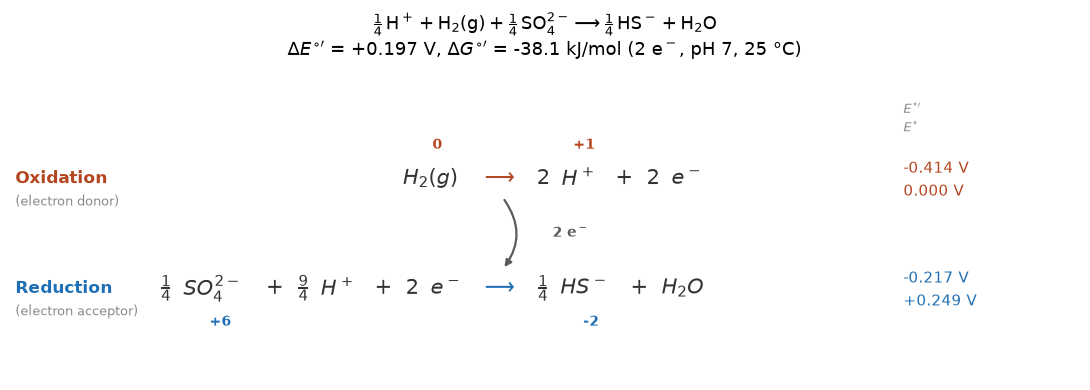

In [8]:
from microbial_thermo.figures import plot_half_reactions

figure = plot_half_reactions(reaction)
plt.show()

### Exercise

Draw the half-reaction diagram for anaerobic methane oxidation coupled to
sulfate reduction, then work out from the figure how many electrons move per
molecule of methane.

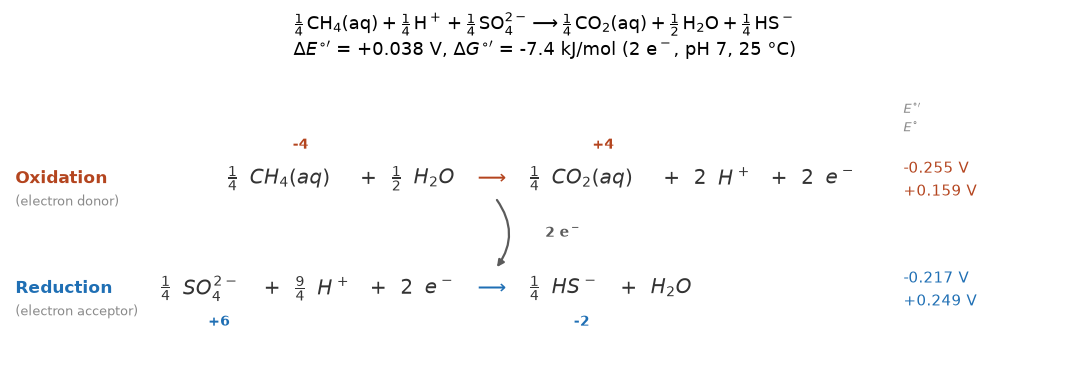

In [9]:
aom = mt.Reaction.from_couples(
    donor=("methane", "CO2(aq)"),
    acceptor=("HS-", "SO4-2"),
    conditions=conditions,
)
plot_half_reactions(aom)
plt.show()